## Train A Test A

### Classification

Category distribution:
4    6463
0    5280
3     231
2     110
5      37
6      31
1      30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.65      0.61      0.63      1034
      Button       0.57      0.67      0.62         6
        Door       0.86      0.66      0.75        38
      Motion       0.70      0.60      0.64        47
      Socket       0.70      0.74      0.72      1305
 Temperature       1.00      0.67      0.80         3
   Vibration       0.67      0.50      0.57         4

    accuracy                           0.68      2437
   macro avg       0.74      0.63      0.67      2437
weighted avg       0.68      0.68      0.68      2437

Macro F1-Score: 0.6749


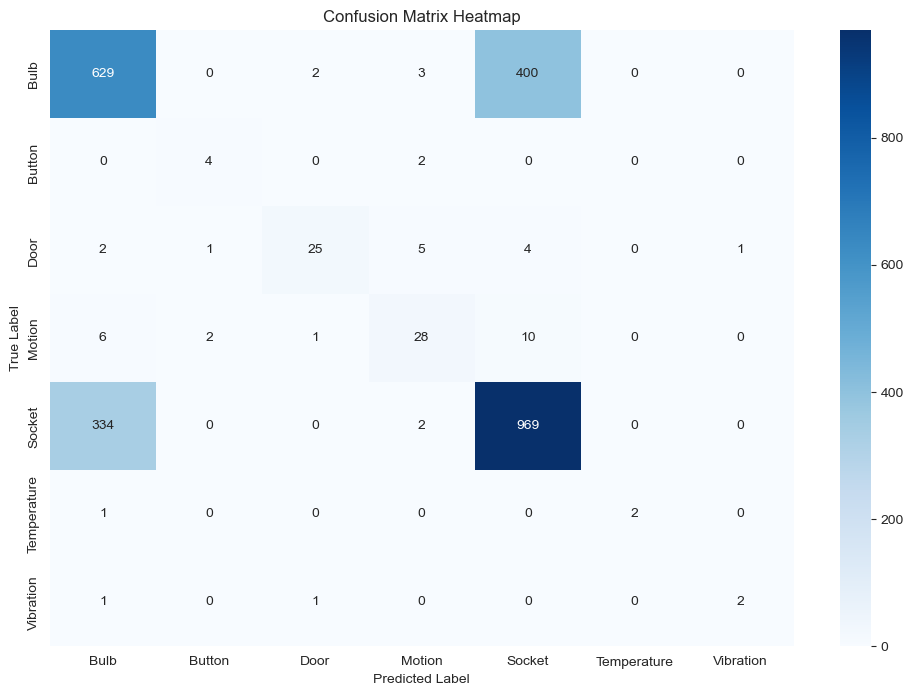

In [9]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    1769
14    1438
13    1390
5     1354
12    1177
8     1160
6     1039
9      863
7      827
10     726
11     166
1       39
20      37
2       33
4       31
0       30
3       26
19      24
16      23
18      15
17      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.75      0.50      0.60         6
        Aqara Door 1       0.75      0.40      0.52        15
        Aqara Door 2       0.33      0.36      0.34        14
        Aqara Motion       1.00      0.71      0.83         7
     Aqara Vibration       1.00      0.50      0.67         4
       Ledvance Bulb       0.37      0.41      0.39       259
Ledvance Smart+ Plug       0.29      0.27      0.28       226
    Ledvance Z3 Plug       0.20      0.18      0.19       163
           Moes Bulb       0.73      0.84      0.78       226
      Philips Lamp 1       0.22      0.19      0.20       176
      Philips Lamp 2       0.24      

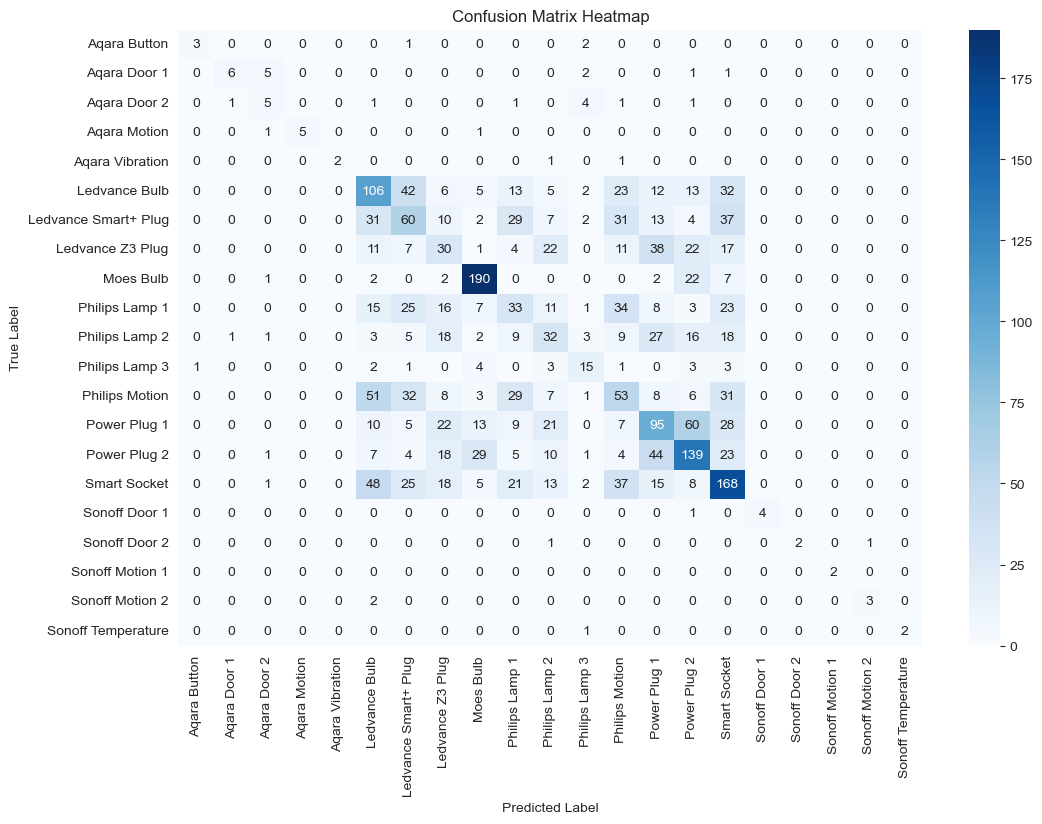

In [10]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    9321
0    6740
3     575
2     195
5     110
1      93
6      39
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.63      0.61      0.62      1314
      Button       0.39      0.41      0.40        22
        Door       0.61      0.66      0.64        41
      Motion       0.70      0.66      0.68       126
      Socket       0.73      0.75      0.74      1878
 Temperature       0.38      0.50      0.43        22
   Vibration       0.25      0.08      0.12        12

    accuracy                           0.68      3415
   macro avg       0.53      0.52      0.52      3415
weighted avg       0.68      0.68      0.68      3415

Macro F1-Score: 0.5183


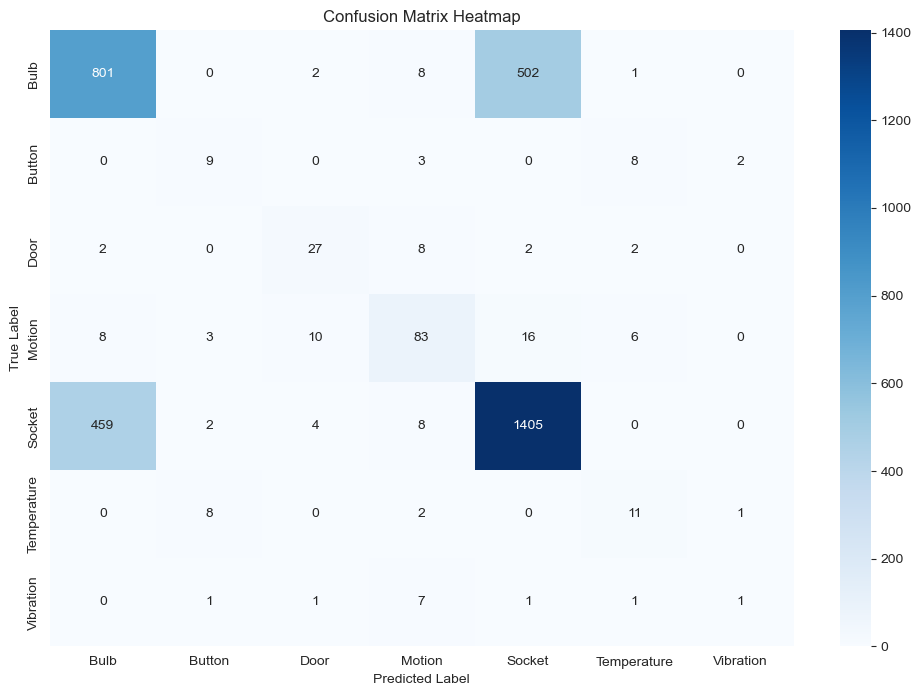

In [11]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    2811
13    2743
5     1791
8     1520
14    1519
7     1346
9     1344
11    1313
6      902
10     772
12     384
3      118
20     110
0       93
16      59
17      53
1       53
18      52
4       39
2       30
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.42      0.50      0.46        22
        Aqara Door 1       0.42      0.42      0.42        12
        Aqara Door 2       0.33      0.50      0.40         8
        Aqara Motion       0.82      0.82      0.82        28
     Aqara Vibration       0.40      0.17      0.24        12
       Ledvance Bulb       0.30      0.30      0.30       357
Ledvance Smart+ Plug       0.17      0.18      0.18       171
    Ledvance Z3 Plug       0.17      0.14      0.15       296
           Moes Bulb       0.53      0.61      0.56       273
      Philips Lamp 1       0.31      0.33      0.32       280
      Philips Lamp 2       0.09      

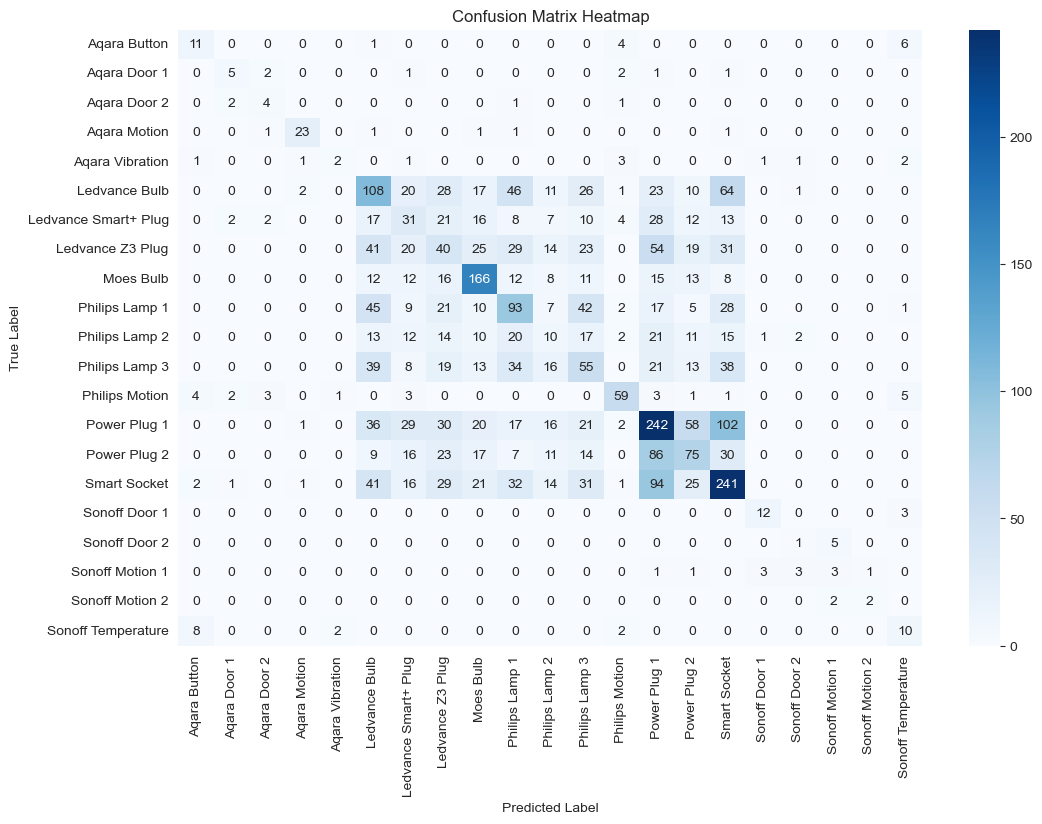

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
4    6463
0    5280
3     231
2     110
5      37
6      31
1      30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.57      0.52      0.54      6740
      Button       0.30      0.24      0.27        93
        Door       0.28      0.22      0.25       195
      Motion       0.60      0.46      0.52       575
      Socket       0.67      0.73      0.70      9321
 Temperature       0.17      0.07      0.10       110
   Vibration       0.00      0.00      0.00        39

    accuracy                           0.62     17073
   macro avg       0.37      0.32      0.34     17073
weighted avg       0.61      0.62      0.62     17073

Macro F1-Score: 0.3389


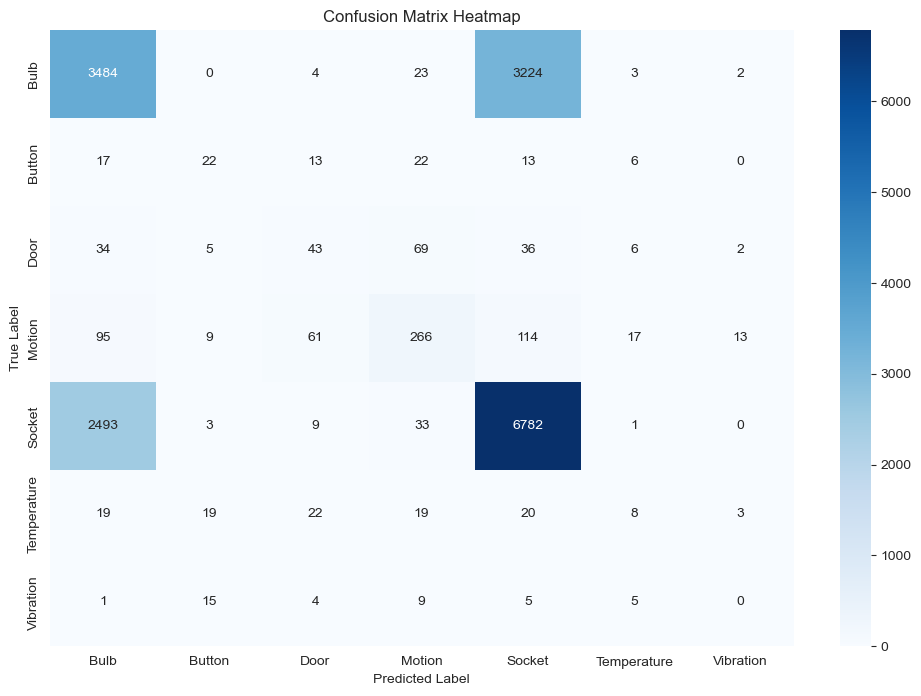

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    1769
14    1438
13    1390
5     1354
12    1177
8     1160
6     1039
9      863
7      827
10     726
11     166
1       39
20      37
2       33
4       31
0       30
3       26
19      24
16      23
18      15
17      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.32      0.22      0.26        93
        Aqara Door 1       0.19      0.09      0.12        53
        Aqara Door 2       0.00      0.00      0.00        30
        Aqara Motion       0.79      0.28      0.41       118
     Aqara Vibration       0.00      0.00      0.00        39
       Ledvance Bulb       0.29      0.28      0.28      1791
Ledvance Smart+ Plug       0.06      0.07      0.06       902
    Ledvance Z3 Plug       0.14      0.17      0.15      1346
           Moes Bulb       0.47      0.44      0.46      1520
      Philips Lamp 1       0.19      0.14      0.16      1344
      Philips Lamp 2       0.08      

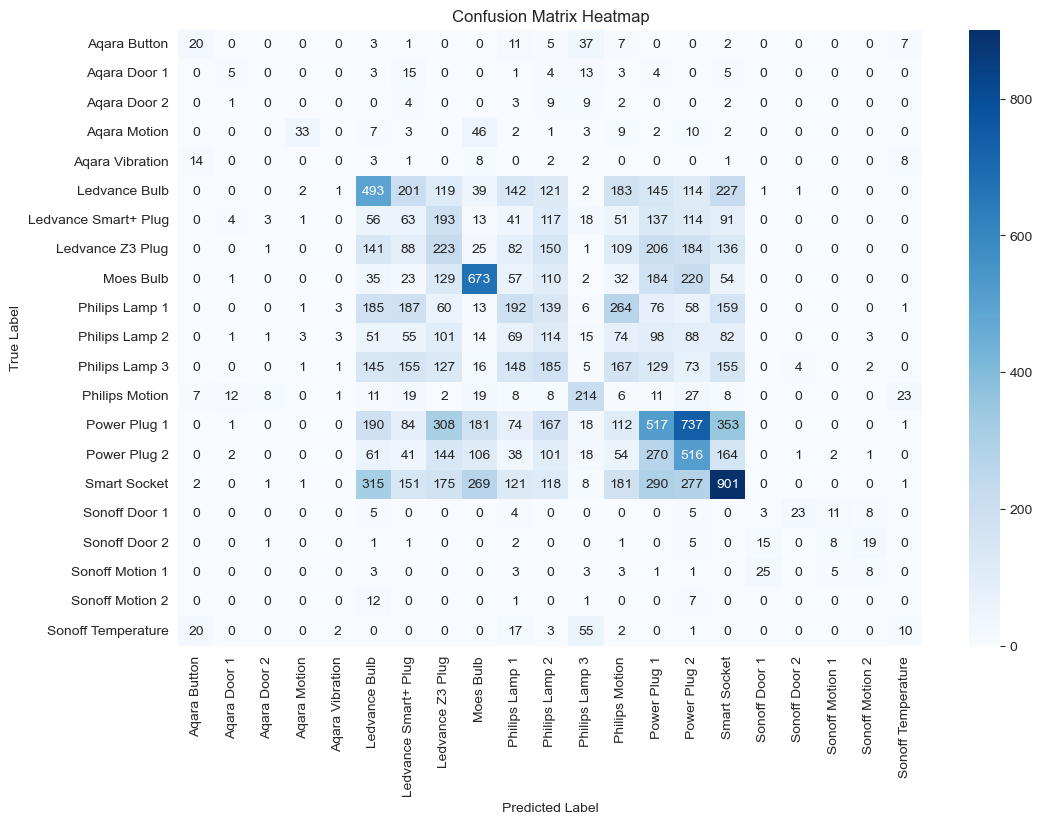

In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    9321
0    6740
3     575
2     195
5     110
1      93
6      39
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.60      0.59      0.60      5280
      Button       0.44      0.37      0.40        30
        Door       0.31      0.28      0.29       110
      Motion       0.39      0.44      0.41       231
      Socket       0.67      0.68      0.68      6463
 Temperature       0.19      0.14      0.16        37
   Vibration       0.00      0.00      0.00        31

    accuracy                           0.63     12182
   macro avg       0.37      0.36      0.36     12182
weighted avg       0.63      0.63      0.63     12182

Macro F1-Score: 0.3629


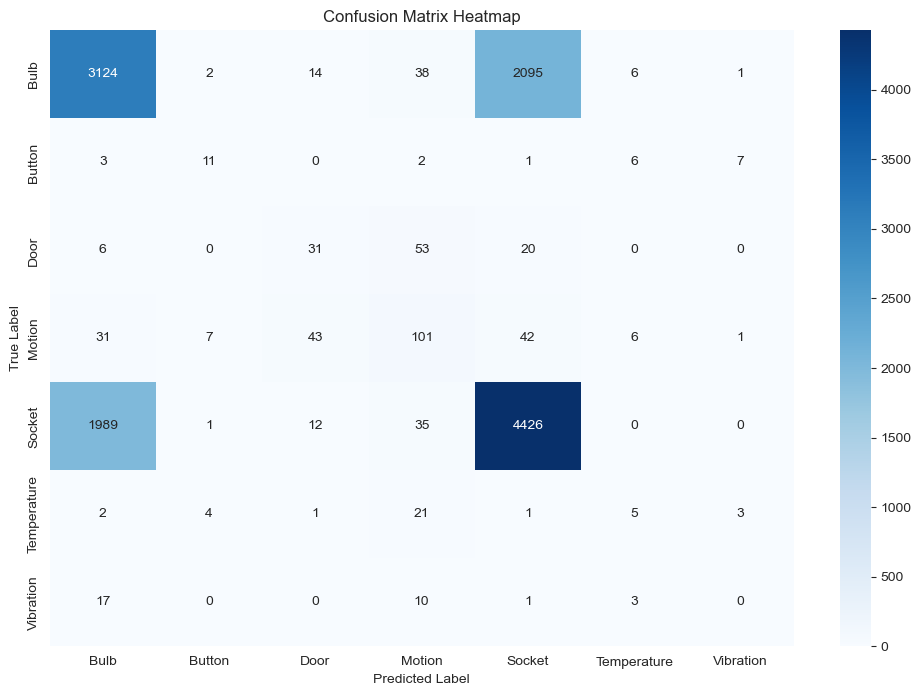

In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    2811
13    2743
5     1791
8     1520
14    1519
7     1346
9     1344
11    1313
6      902
10     772
12     384
3      118
20     110
0       93
16      59
17      53
1       53
18      52
4       39
2       30
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.38      0.40      0.39        30
        Aqara Door 1       0.27      0.21      0.23        39
        Aqara Door 2       0.09      0.03      0.05        33
        Aqara Motion       0.54      0.81      0.65        26
     Aqara Vibration       0.00      0.00      0.00        31
       Ledvance Bulb       0.33      0.37      0.35      1354
Ledvance Smart+ Plug       0.10      0.05      0.07      1039
    Ledvance Z3 Plug       0.14      0.13      0.14       827
           Moes Bulb       0.56      0.65      0.60      1160
      Philips Lamp 1       0.16      0.24      0.19       863
      Philips Lamp 2       0.10      

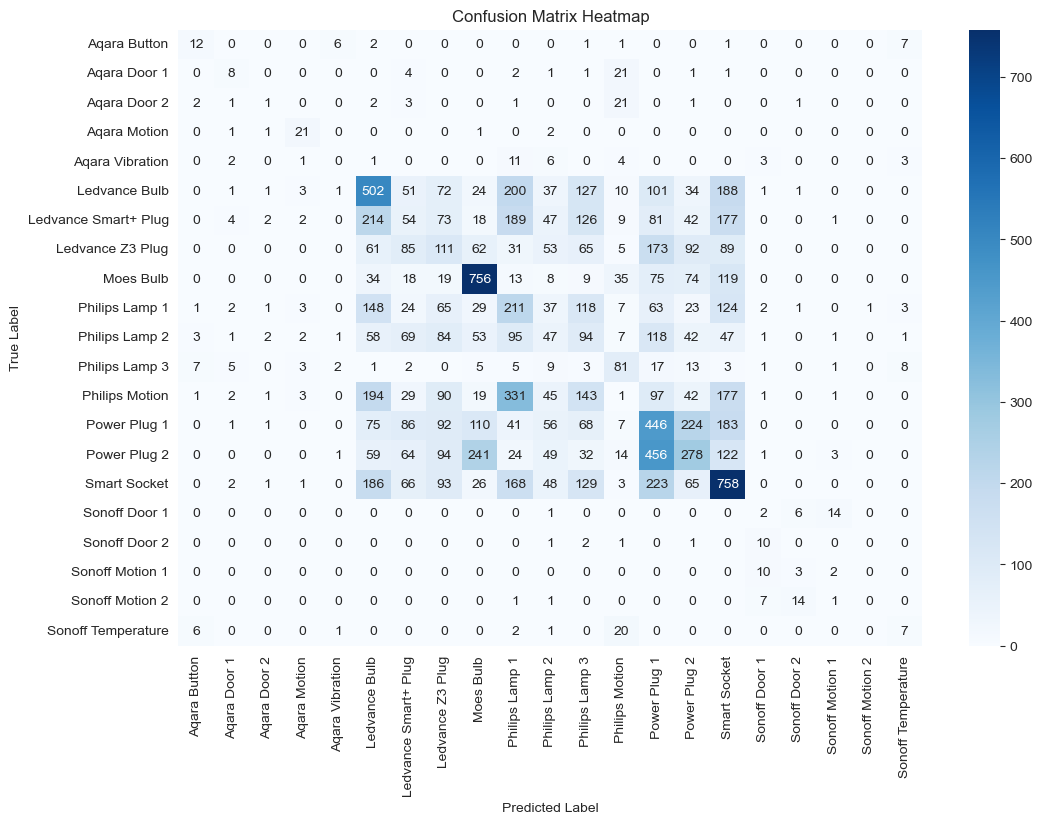

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
